# Initial Data Visualization
Import the datafile for choice 1 into python and visualize x and y data. 


,Mass,x,y,z,Vx,Vy,Vz,softening,potential
0,,,,,,,,,
0,92.4259,-0.003816,-0.079670,-0.019072,3779.62,354.734,-73.45010,0.1,0.013022
1,92.4259,-0.032298,-0.249461,-0.010890,3250.59,-674.280,-18.33470,0.1,0.013022
2,92.4259,0.067577,-0.810356,-0.006849,2190.86,199.053,3.86061,0.1,0.013022
3,92.4259,-0.152755,0.276704,-0.002704,-2695.14,-1345.020,105.94600,0.1,0.013022
4,92.4259,-0.216623,0.150557,-0.002755,-1811.89,-2595.570,85.85910,0.1,0.013022


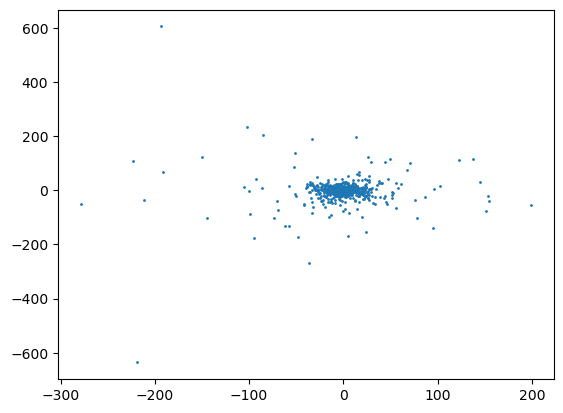

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

path = r'C:\Users\UZH\OneDrive - Universität Zürich UZH\Dokumente\HS25\Computational Astrophysics\N_Body_Repo\N_Body\Prerequisites\Data for choice 1\data.txt'
galaxy = pd.read_csv(path, sep = '\t', header = None, index_col=0)
colnames = ["Mass", "x", "y", "z", "Vx", "Vy", "Vz", "softening", "potential"]
galaxy.columns = colnames
galaxy.head()
galaxy.shape

plt.scatter(data = galaxy, x="x",y="y", s = 1);
# plt.xlim([-25,25])
# plt.ylim([-25,25])
galaxy.head()

# Calculate radial range
calculate the distance for each particle from 0,0 to afterwards put them into the bins

In [11]:
## calc radial range
galaxy["radial_range"] = np.linalg.norm(galaxy[["x","y","z"]].values, axis = 1)
# ## generate histogram wit bins
# num_bins = 10000
# hist, bins = np.histogram(galaxy.radial_range, bins = num_bins)
# plt.loglog(bins[:-1:],hist)

# ## get volume of bins
# ### get furthest distance from center and calculate bin volume
# max_range = max(galaxy.radial_range)
# bin_volume = max_range/num_bins

# ## calculate density function of numerical data
# density_func_numerical_data = hist/bin_volume
# x_vals = bins[:-1:]
# ## calculate poissonian errorbars
# poiss_error = np.sqrt(density_func_numerical_data/bin_volume)
# plt.loglog(x_vals,density_func_numerical_data);



50010

# generate Hernquist distribution
Generate the analytical distibution from the Hernquist paper

In [ ]:
radius_range = np.linspace(0,max_range,num_bins+1)
radius_range = radius_range[1::]
tot_Mass = sum(galaxy.Mass)
a = 3
pi = np.pi
hernquist_Dist = (tot_Mass/(2*pi))*a/(radius_range*(radius_range+a)**3)
plt.loglog(x_vals, hernquist_Dist);


In [ ]:
dP = plt.Figure((10,8))
plt.errorbar(x_vals,density_func_numerical_data, poiss_error, color = "blue", marker = ".", markersize = 1, linewidth = 0)
plt.plot(x_vals, hernquist_Dist, color = 'orange')
plt.semilogx()
plt.semilogy()
plt.xlabel("radial range / parsec")
plt.ylabel("density function / solar mass/parsec^3")

# Repeat analysis with logarithmic bins


[   4    1    2    8   20   38   79  156  302  547  907 1494 2260 3234
 4241 5095 5351 5185 4753 3994 3237 2497 1858 1338 1032  689  528  396
  244  168  112   81   60   31   23   17   14   11    1    2] [4.02606477e-10 1.19444528e-09 3.54365767e-09 1.05132565e-08
 3.11905307e-08 9.25354764e-08 2.74532501e-07 8.14477832e-07
 2.41637743e-06 7.16886285e-06 2.12684467e-05 6.30988254e-05
 1.87200402e-04 5.55382612e-04 1.64769863e-03 4.88836113e-03
 1.45026973e-02 4.30263281e-02 1.27649697e-01 3.78708705e-01
 1.12354582e+00 3.33331450e+00 9.88921441e+00 2.93391343e+01
 8.70427887e+01 2.58236899e+02 7.66132348e+02 2.27294696e+03
 6.74333605e+03 2.00060019e+04 5.93534279e+04 1.76088627e+05
 5.22416409e+05 1.54989512e+06 4.59819953e+06 1.36418514e+07
 4.04723867e+07 1.20072711e+08 3.56229449e+08 1.05685479e+09] [9.18275342e+11 7.73797691e+10 5.21641246e+10 7.03309386e+10
 5.92653591e+10 3.79550021e+10 2.65966546e+10 1.77026800e+10
 1.15514329e+10 7.05229942e+09 3.94153332e+09 2.18838138e+09
 1

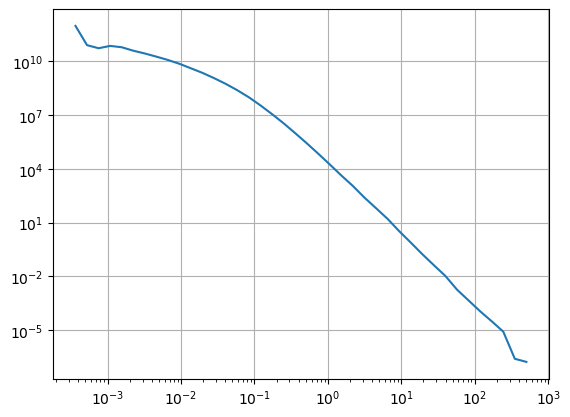

In [17]:
num_bins = 40
bins = np.logspace(np.log10(min(galaxy.radial_range)), np.log10(max(galaxy.radial_range)), num_bins+1)

hist, bin_edges = np.histogram(galaxy.radial_range, bins = bins)
# bin_volumes = np.diff(bin_edges)
bin_volumes = (4.0 * np.pi / 3.0) * (bin_edges[1:] **3 - bin_edges[:-1] **3)

# plt.loglog(bins[:-1:],hist)

## calculate density function of numerical data


density_func_numerical_data = (hist*92.4259)/bin_volumes
print(hist, bin_volumes, density_func_numerical_data)

x_vals = bins[:-1:]
## calculate poissonian errorbars
# poiss_error = np.sqrt(density_func_numerical_data/bin_volumes)
poiss_error = np.sqrt(hist)*92.4259/bin_volumes
plt.loglog(x_vals,density_func_numerical_data);
plt.grid()


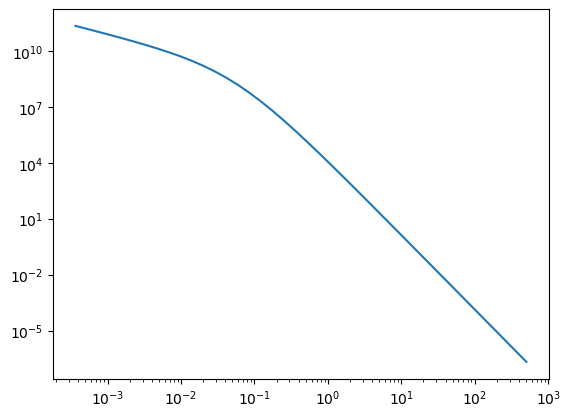

In [7]:
radius_range = bins
radius_range = radius_range[1::]
tot_Mass = sum(galaxy.Mass)
a = 0.078
pi = np.pi
hernquist_Dist = (tot_Mass/(2*pi))*a/(radius_range*(radius_range+a)**3)
plt.loglog(x_vals, hernquist_Dist);

array([4.59137671e+11, 7.73797691e+10, 3.68856062e+10, 2.48657418e+10,
       1.32521372e+10, 6.15711438e+09, 2.99235742e+09, 1.41734873e+09,
       6.64710271e+08, 3.01534549e+08, 1.30876466e+08, 5.66171119e+07,
       2.34715155e+07, 9.46392778e+06, 3.65300313e+06, 1.34959202e+06,
       4.66189385e+05, 1.54679865e+05, 4.99180726e+04, 1.54238371e+04,
       4.68030600e+03, 1.38556425e+03, 4.02860558e+02, 1.15232358e+02,
       3.41114940e+01, 9.39474509e+00, 2.77208696e+00, 8.09192744e-01,
       2.14098586e-01, 5.98808594e-02, 1.64799881e-02, 4.72394562e-03,
       1.37041626e-03, 3.32026100e-04, 9.63983928e-05, 2.79347529e-05,
       8.54474073e-06, 2.55297001e-06, 2.59456090e-07, 1.23678259e-07])

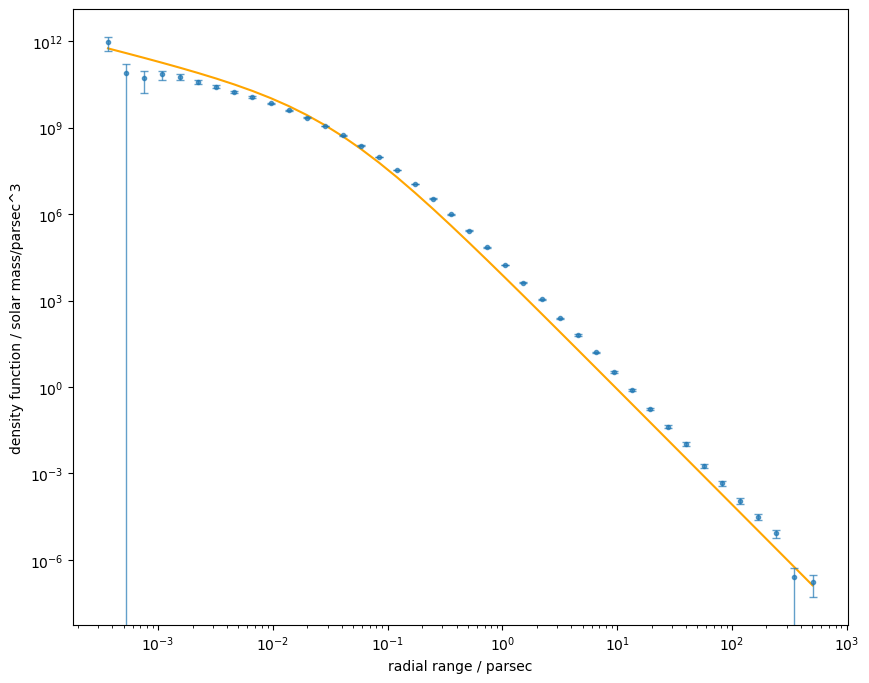

In [18]:
dP = plt.figure(figsize=(10,8))
plt.xscale('log')
plt.yscale('log')
plt.plot(x_vals, hernquist_Dist, color = 'orange')
plt.errorbar(x_vals, density_func_numerical_data, yerr=poiss_error, 
             fmt='o', markersize=3, capsize=3, elinewidth=1, 
             label='Numerical data', alpha=0.7)
plt.xlabel("radial range / parsec");
plt.ylabel("density function / solar mass/parsec^3");
poiss_error

# Fit a to the data
using an optimization algorithm, i fit a to the datapoints

In [9]:
from scipy.optimize import minimize_scalar
def hernquist_density(r, M, a):
    """calculate the hernquist distribution based on inputs r, M and a"""
    return (M/(2*np.pi))*a/(r*(r+a)**3)

def cost_function(a, r_data, rho_data, M):
    """calculate the R^2 based on the experimental density and the calculated hernquist density"""
    rho_model = hernquist_density(r_data, M, a)
    return np.sum((rho_data - rho_model)**2)

# optimize a so that the R^2 of the data is minimized using scipy's optimize methods
initial_guess = 1 # initial guess for a
optimal_result = minimize_scalar(cost_function, args = (radius_range, density_func_numerical_data, tot_Mass))
a = round(optimal_result.x, 4) # optimized value for a


# recalculate and plot the fit of the hernquist distribution with the right a


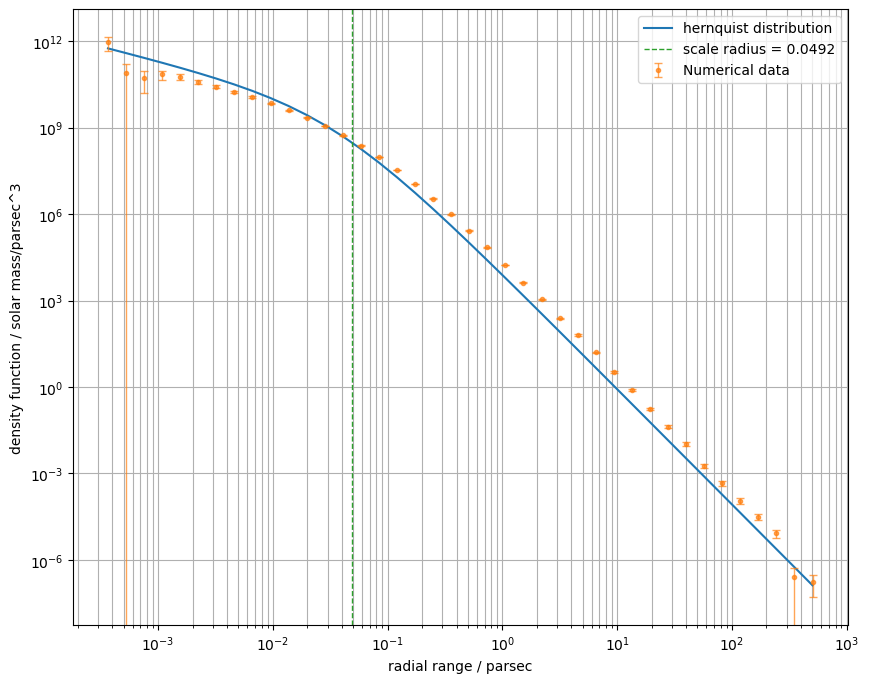

In [19]:
hernquist_Dist = hernquist_density(radius_range, tot_Mass, a)


dP = plt.figure(figsize=(10,8))
plt.plot(x_vals, hernquist_Dist, color = "tab:blue", label = "hernquist distribution")
plt.errorbar(x_vals, density_func_numerical_data, yerr=poiss_error, 
             fmt='o', markersize=3, capsize=3, elinewidth=1, 
             label='Numerical data', alpha=0.7, color = "tab:orange")
plt.xscale('log')
plt.yscale('log')
plt.xlabel("radial range / parsec");
plt.ylabel("density function / solar mass/parsec^3");
plt.vlines(a,ymin = 0, ymax = 10**15, color = "tab:green", linestyles="--", linewidth = 1, label = f"scale radius = {a}")
plt.legend()
plt.grid(which = 'both', axis = "both")

# Calculate mean interparticle distance
use particles included in the half mass radius to calculate an estimate for the mean interparticle distance

In [ ]:

def calc_R_halfmass(galaxy):
    """returns halfmass radius in parsec"""
    integrated_mass = 0
    galaxy_sorted = galaxy
    half_mass = sum(galaxy["Mass"])/2

    galaxy_sorted.sort_values("radial_range")
    for index, row in galaxy_sorted.iterrows():
        integrated_mass+=row["Mass"]
        if integrated_mass>half_mass:
            return row["radial_range"]
        
def calc_mean_interparticle_distance(galaxy):
    """calculate the mean interparticle distance of a galaxy based on the half mass radius"""
    half_mass_radius = calc_R_halfmass(galaxy)
    galaxy_halfmass = galaxy[galaxy["radial_range"]<half_mass_radius]
    return sum(galaxy_halfmass.radial_range/galaxy_halfmass.size)
    
mean_interparticle_distance = calc_mean_interparticle_distance(galaxy)



0.048596998711201725